<a href="https://colab.research.google.com/github/psy0635-ctrl/OpenCv/blob/main/%EC%98%81%EC%83%81%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5%EC%B2%98%EB%A6%AC_0331.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python

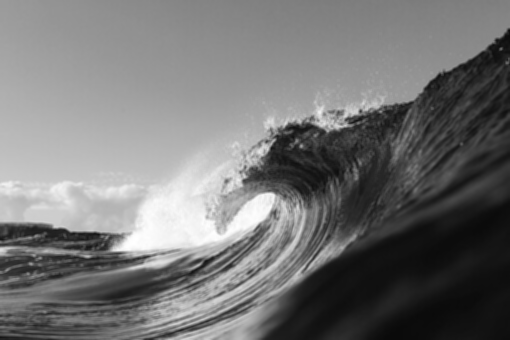

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/sea.png',cv2.IMREAD_GRAYSCALE )  # 흑백 이미지 불러오기

# 3 x 3 평균 필터 직접 제작
kernel = np.ones((3,3),np.float32) / 9      # 3×3 크기의 표를 만들고, 모든 칸을 1/9로 채움 --> 주변 9개 픽셀의 평균을 내겠다.

result = cv2.filter2D(img,-1,kernel)        #이미지의 모든 픽셀을 돌아다니면서, 해당 픽셀과 주변 8개 픽셀의 밝기를 평균 내서 새 값으로 바꿔요.

cv2_imshow(result)         #픽셀 하나하나를 주변 9개의 평균값으로 바꾸면 → 날카로운 경계가 부드러워지면서 이미지가 흐릿해져요 (노이즈 제거 효과도 있어요)

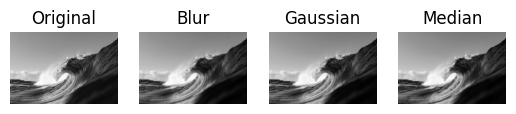

In [6]:
import matplotlib.pyplot as plt

# 이미지 불러오기
titles = ['Original', 'Blur', 'Gaussian', 'Median']
imgs = [img, cv2.blur(img,(5,5)),
        cv2.GaussianBlur(img,(5,5),0),
        cv2.medianBlur(img,5)]

for i, (t, im) in enumerate(zip(titles, imgs)):
    plt.subplot(1, 4, i+1)  # 1행 4열 중 i+1번째 칸
    plt.imshow(im, cmap='gray')
    plt.title(t)
    plt.axis('off')
plt.show()


In [16]:
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobel_x,sobel_y)
sobel = np.uint8(np.clip(sobel,0,255))

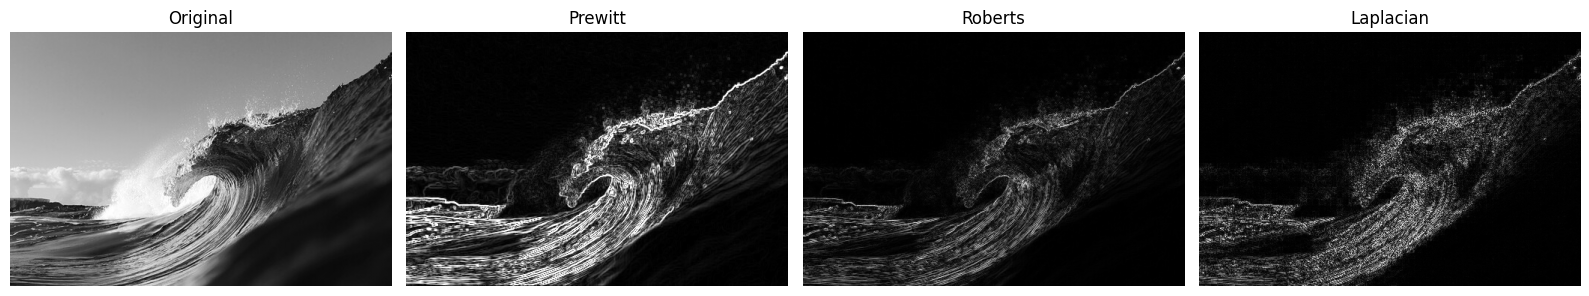

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# 이미지 불러오기 (흑백)
img = cv2.imread('/content/sea.png', cv2.IMREAD_GRAYSCALE)

# ── 1. 프리윗 필터 ──────────────────────────
Px = np.array([[-1, 0, 1],
               [-1, 0, 1],
               [-1, 0, 1]], dtype=np.float32)

Py = np.array([[-1, -1, -1],
               [ 0,  0,  0],
               [ 1,  1,  1]], dtype=np.float32)

prewitt_x = cv2.filter2D(img, cv2.CV_64F, Px)
prewitt_y = cv2.filter2D(img, cv2.CV_64F, Py)
prewitt = np.uint8(np.clip(cv2.magnitude(prewitt_x, prewitt_y), 0, 255))

# ── 2. 로버츠 필터 ──────────────────────────
Rx = np.array([[ 0,  0, -1],
               [ 0,  1,  0],
               [ 0,  0,  0]], dtype=np.float32)

Ry = np.array([[-1,  0,  0],
               [ 0,  1,  0],
               [ 0,  0,  0]], dtype=np.float32)

roberts_x = cv2.filter2D(img, cv2.CV_64F, Rx)
roberts_y = cv2.filter2D(img, cv2.CV_64F, Ry)
roberts = np.uint8(np.clip(cv2.magnitude(roberts_x, roberts_y), 0, 255))

# ── 3. 라플라시안 필터 ───────────────────────
laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian = np.uint8(np.abs(laplacian))

# ── 결과 출력 ────────────────────────────────
titles = ['Original', 'Prewitt', 'Roberts', 'Laplacian']
imgs    = [img, prewitt, roberts, laplacian]

plt.figure(figsize=(16, 4))
for i, (t, im) in enumerate(zip(titles, imgs)):
    plt.subplot(1, 4, i+1)
    plt.imshow(im, cmap='gray')
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()

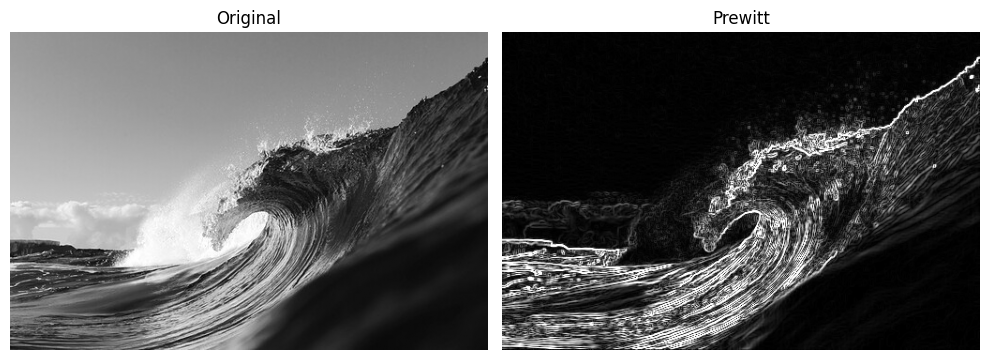

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/sea.png', cv2.IMREAD_GRAYSCALE)

Px = np.array([[-1, 0, 1],
               [-1, 0, 1],
               [-1, 0, 1]], dtype=np.float32)

Py = np.array([[-1, -1, -1],
               [ 0,  0,  0],
               [ 1,  1,  1]], dtype=np.float32)

prewitt_x = cv2.filter2D(img, cv2.CV_64F, Px)
prewitt_y = cv2.filter2D(img, cv2.CV_64F, Py)
prewitt = np.uint8(np.clip(cv2.magnitude(prewitt_x, prewitt_y), 0, 255))

titles = ['Original', 'Prewitt']
imgs = [img, prewitt]
plt.figure(figsize=(10, 4))
for i, (t, im) in enumerate(zip(titles, imgs)):
    plt.subplot(1, 2, i+1)
    plt.imshow(im, cmap='gray')
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()

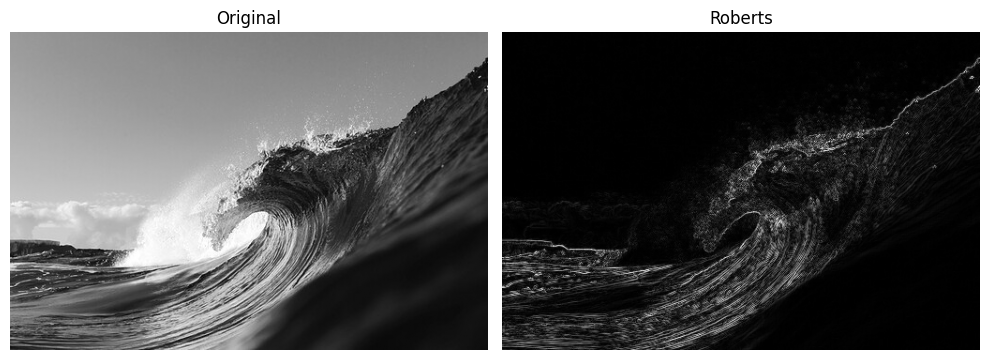

In [18]:
Rx = np.array([[ 0,  0, -1],
               [ 0,  1,  0],
               [ 0,  0,  0]], dtype=np.float32)

Ry = np.array([[-1,  0,  0],
               [ 0,  1,  0],
               [ 0,  0,  0]], dtype=np.float32)

roberts_x = cv2.filter2D(img, cv2.CV_64F, Rx)
roberts_y = cv2.filter2D(img, cv2.CV_64F, Ry)
roberts = np.uint8(np.clip(cv2.magnitude(roberts_x, roberts_y), 0, 255))

titles = ['Original', 'Roberts']
imgs = [img, roberts]
plt.figure(figsize=(10, 4))
for i, (t, im) in enumerate(zip(titles, imgs)):
    plt.subplot(1, 2, i+1)
    plt.imshow(im, cmap='gray')
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_11962/321867326.py:26: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11962/321867326.py:26: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11962/321867326.py:26: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11962/321867326.py:26: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11962/321867326.py:26: UserWarning: Glyph 49380 (\N{HANGUL SYLLABLE SYA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11962/321867326.py:26: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11962/321867326.py:26: UserWarning: Glyph 45789 (\N{HANGUL SYLLABLE NING}) missing from font(s) DejaVu Sans.
  plt.tight_l

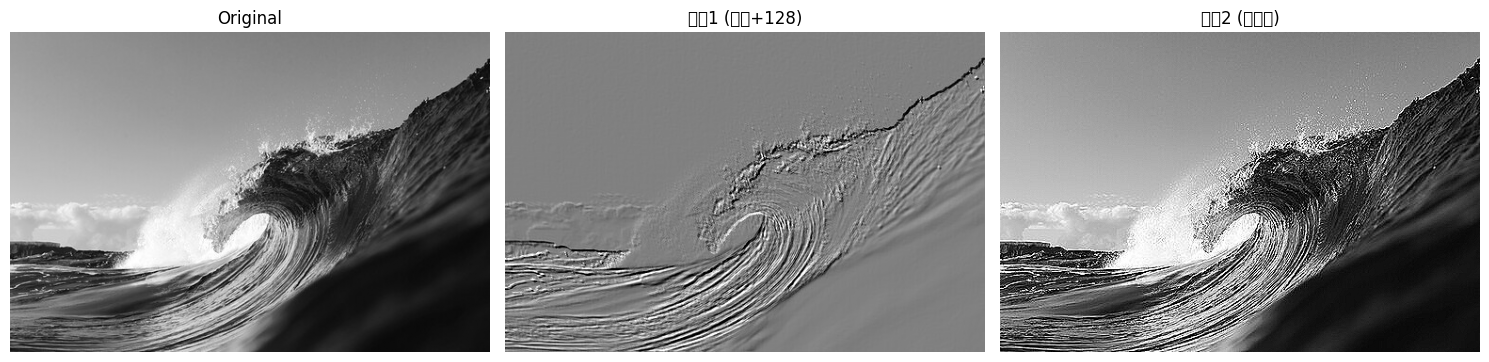

In [21]:
# 작업 1: 대각선 차분 커널 + 128  -->  차분 (Difference) : 원본 영상에서
kernel1 = np.array([[-1, 0, 0],                           #이웃 픽셀끼리 빼는 것
                    [ 0, 0, 0],
                    [ 0, 0, 1]], dtype=np.float32)

result1 = cv2.filter2D(img, cv2.CV_64F, kernel1)
result1 = np.uint8(np.clip(result1 + 128, 0, 255))

# 작업 2: 라플라시안 커널 + 원본 --> 샤프닝 : 이미지를 더 선명하게 만드는 작업
kernel2 = np.array([[ 0, -1,  0],
                    [-1,  4, -1],
                    [ 0, -1,  0]], dtype=np.float32)

result2 = cv2.filter2D(img, cv2.CV_64F, kernel2)
result2 = np.uint8(np.clip(result2 + img, 0, 255))

# 결과 출력
titles = ['Original', '작업1 (차분+128)', '작업2 (샤프닝)']
imgs_list = [img, result1, result2]
plt.figure(figsize=(15, 4))
for i, (t, im) in enumerate(zip(titles, imgs_list)):
    plt.subplot(1, 3, i+1)
    plt.imshow(im, cmap='gray')
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()